#### A. Librerías, variables, funciones y lectura de datos.

In [59]:
#1. Importo librerías.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import holidays
from scipy import signal

In [60]:
#2. Lectura de datos.
series_temporales = pd.read_csv("../dataset.csv")
diccionario = pd.read_excel("../diccionario.xlsx",sheet_name="metadata")

#### B. EDA.

In [61]:
#1. Columnas y variables.
print("Tenemos {} columnas. Estas son: {}".format(series_temporales.shape[1],series_temporales.columns))

Tenemos 37 columnas. Estas son: Index(['fecha', 'merval_apertura', 'merval_maximo', 'merval_minimo',
       'merval_cierre', 'embi_spread_arg', 'embi_spreads_brz',
       'embi_spread_global', 'emae_original', 'emae_desestacionalizado',
       'emae_tendencia_ciclo', 'tc_minorista', 'tc_mayorista', 'rrii', 'tamar',
       'badlar', 'tm20', 'tasa_prestamos_personales', 'tasa_pf_pesos',
       'tasa_pf_dolares', 'base_monetaria', 'circulacion_monetaria',
       'dep_ccorrientes', 'dep_cahorro', 'dep_plazo', 'dep_plazo_fijo', 'm1',
       'm2', 'm2_transaccional', 'dep_dolar_priv_ars',
       'prestamos_privados_pesos_ars', 'prestamos_privados_dolares_ars',
       'prestamos_privados_ars', 'inflacion', 'rem', 'cer', 'uva'],
      dtype='object')


In [62]:
#2. Información general de las variables.
series_temporales.info() 

# Tenemos series temporales con datos nulos......

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4487 entries, 0 to 4486
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   fecha                           3599 non-null   object 
 1   merval_apertura                 3599 non-null   float64
 2   merval_maximo                   3599 non-null   float64
 3   merval_minimo                   3599 non-null   float64
 4   merval_cierre                   3599 non-null   float64
 5   embi_spread_arg                 3468 non-null   float64
 6   embi_spreads_brz                3468 non-null   float64
 7   embi_spread_global              3468 non-null   float64
 8   emae_original                   3576 non-null   float64
 9   emae_desestacionalizado         3576 non-null   float64
 10  emae_tendencia_ciclo            3576 non-null   float64
 11  tc_minorista                    3577 non-null   float64
 12  tc_mayorista                    35

In [63]:
#3. Convertimos tipo de datos de la fecha a datetime y la ordenamos por dicha variable.
series_temporales["fecha"] = pd.to_datetime(series_temporales["fecha"])
series_temporales = series_temporales.sort_values("fecha")

In [64]:
#4. Borramos filas enteras con NA.
series_temporales.dropna(how='all', inplace=True)

In [65]:
#5. Entendemos las fechas de inicio y fin de la Serie temporal
inicio = series_temporales["fecha"].sort_values(ascending=True).iloc[0]
fin = series_temporales["fecha"].sort_values(ascending=False).iloc[0]

print(f"Las series temporales son algunas diarias, y otras mensuales, yendo desde {inicio} a {fin}.")

Las series temporales son algunas diarias, y otras mensuales, yendo desde 2011-01-03 00:00:00 a 2025-09-30 00:00:00.


In [66]:
#6. Nos quedamos con la información de 01/2025 hasta 04/2025 (coincidente con las fechas de las noticias screappeadas).
series_temporales = series_temporales[(series_temporales["fecha"] >= "2025-01-01")&(series_temporales["fecha"] <= "2025-04-30")]

In [67]:
#7. Tiene fechas repetidas?
print("Fechas unicas: {}".format(series_temporales["fecha"].nunique()))
print("Cantidad de filas totales: {}".format(series_temporales.shape[0]))

Fechas unicas: 79
Cantidad de filas totales: 79


In [68]:
#8. Entre el inicio y fin hay 79 fechas?
inicio = series_temporales["fecha"].sort_values(ascending=True).iloc[0]
fin = series_temporales["fecha"].sort_values(ascending=False).iloc[0]

print("Tenemos una apertura de fechas de {} días".format(fin - inicio))
print("Debería cubrir {} días".format(series_temporales.shape[0]))

Tenemos una apertura de fechas de 118 days 00:00:00 días
Debería cubrir 79 días


In [69]:
#9. Que fechas faltan?
#a. Análisis general.
inicio = series_temporales["fecha"].min()
fin = series_temporales["fecha"].max()

rango_completo = pd.date_range(start=inicio, end=fin, freq='D')

fechas_reales = series_temporales["fecha"].unique()

fechas_faltantes = rango_completo.difference(fechas_reales)

#print("Cantidad de fechas faltantes:", len(fechas_faltantes))
#print("Fechas faltantes:")
#print(fechas_faltantes)
#print("-------------------------------------------------------------------")
#b. Análisis de días de la semana.
faltantes_df = pd.DataFrame(fechas_faltantes, columns=["fecha"])
faltantes_df["dia_semana"] = faltantes_df["fecha"].dt.day_name(locale="es_ES")
faltantes_laborales = faltantes_df[
    ~faltantes_df["dia_semana"].isin(["Sábado", "Domingo"])
]

#print("Cantidad de fechas faltantes en días hábiles:", len(faltantes_laborales))
#print(faltantes_laborales)
#print("-------------------------------------------------------------------")

#c. Excluimos los feriados nacionales.
feriados_ar = holidays.AR(years=range(inicio.year, fin.year + 1))
faltantes_laborales["es_feriado"] = faltantes_laborales["fecha"].isin(feriados_ar)
faltantes_no_fds_ni_feriados = faltantes_laborales[~(faltantes_laborales["es_feriado"])]

print("Cantidad de fechas faltantes que no son fin de semana ni feriados:", len(faltantes_no_fds_ni_feriados))
print(faltantes_no_fds_ni_feriados)

Cantidad de fechas faltantes que no son fin de semana ni feriados: 0
Empty DataFrame
Columns: [fecha, dia_semana, es_feriado]
Index: []


C:\Users\i_link\AppData\Local\Temp\ipykernel_24360\803660515.py:29: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  faltantes_laborales["es_feriado"] = faltantes_laborales["fecha"].isin(feriados_ar)
C:\Users\i_link\AppData\Local\Temp\ipykernel_24360\803660515.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faltantes_laborales["es_feriado"] = faltantes_laborales["fecha"].isin(feriados_ar)


In [70]:
#10. Analisis estadísticos descriptivos básicos de las series temporales.
series_temporales.describe()

,fecha,merval_apertura,merval_maximo,merval_minimo,merval_cierre,embi_spread_arg,embi_spreads_brz,embi_spread_global,emae_original,emae_desestacionalizado,...,m2,m2_transaccional,dep_dolar_priv_ars,prestamos_privados_pesos_ars,prestamos_privados_dolares_ars,prestamos_privados_ars,inflacion,rem,cer,uva
count,79,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,77.000000,77.000000,77.000000,79.000000,79.000000,...,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,79.000000,79.000000,7.900000e+01,79.000000
mean,2025-02-28 07:53:55.443037952,2.397407e+06,2.444995e+06,2.343692e+06,2.390382e+06,709.039143,226.826000,305.176312,148.916818,152.093636,...,6.555726e+07,4.632403e+07,1.120710e+08,5.921435e+07,1.424513e+07,7.345948e+07,2.736709,23.626582,5.411814e+06,1364.895190
min,2025-01-02 00:00:00,1.990621e+06,2.129440e+06,1.889590e+06,1.990621e+06,558.677000,210.583000,282.660000,141.201463,150.564766,...,6.061839e+07,4.364656e+07,1.067833e+08,5.266664e+07,1.121153e+07,6.398713e+07,2.200000,21.900000,5.163055e+06,1301.850000
25%,2025-01-29 12:00:00,2.258239e+06,2.299915e+06,2.196420e+06,2.251496e+06,640.910000,221.751000,291.478000,143.747794,152.097748,...,6.338049e+07,4.473998e+07,1.097258e+08,5.604782e+07,1.330573e+07,6.962718e+07,2.200000,21.900000,5.280051e+06,1332.240000
50%,2025-02-26 00:00:00,2.364530e+06,2.397160e+06,2.332450e+06,2.361583e+06,707.490000,226.234000,297.303000,146.294126,152.097748,...,6.483010e+07,4.610042e+07,1.113860e+08,5.885353e+07,1.460877e+07,7.359341e+07,2.400000,22.200000,5.401438e+06,1362.980000
75%,2025-03-29 12:00:00,2.528641e+06,2.565370e+06,2.476430e+06,2.517266e+06,749.738000,230.315000,316.293000,150.408941,152.786673,...,6.712560e+07,4.785199e+07,1.140345e+08,6.359978e+07,1.530915e+07,7.889355e+07,2.800000,24.500000,5.534335e+06,1395.465000
max,2025-04-30 00:00:00,2.829730e+06,2.867770e+06,2.782480e+06,2.829730e+06,992.595000,253.062000,353.552000,158.661454,153.187431,...,7.458197e+07,5.114923e+07,1.241879e+08,6.813397e+07,1.704374e+07,8.517771e+07,3.700000,26.300000,5.707380e+06,1439.560000
std,NaN,1.988558e+05,1.962081e+05,2.041903e+05,2.032102e+05,92.774838,8.011381,19.391679,6.391238,0.931123,...,3.007020e+06,1.830459e+06,3.497738e+06,4.421248e+06,1.574266e+06,5.931419e+06,0.570465,1.810986,1.544226e+05,38.729557


#### C. Selección de variables (Feature Selection).

##### 1. Análisis estadístico.

                                merval_apertura  merval_maximo  merval_minimo  \
merval_apertura                        1.000000       0.964331       0.965375   
merval_maximo                          0.964331       1.000000       0.964114   
merval_minimo                          0.965375       0.964114       1.000000   
merval_cierre                          0.927232       0.977139       0.966906   
embi_spread_arg                       -0.749513      -0.763203      -0.780844   
embi_spreads_brz                      -0.178793      -0.166575      -0.262575   
embi_spread_global                    -0.616731      -0.600767      -0.677759   
emae_original                         -0.506325      -0.482287      -0.533811   
emae_desestacionalizado                0.051636       0.036460       0.025671   
emae_tendencia_ciclo                  -0.840426      -0.851584      -0.834322   
tc_minorista                          -0.544967      -0.538403      -0.523707   
tc_mayorista                

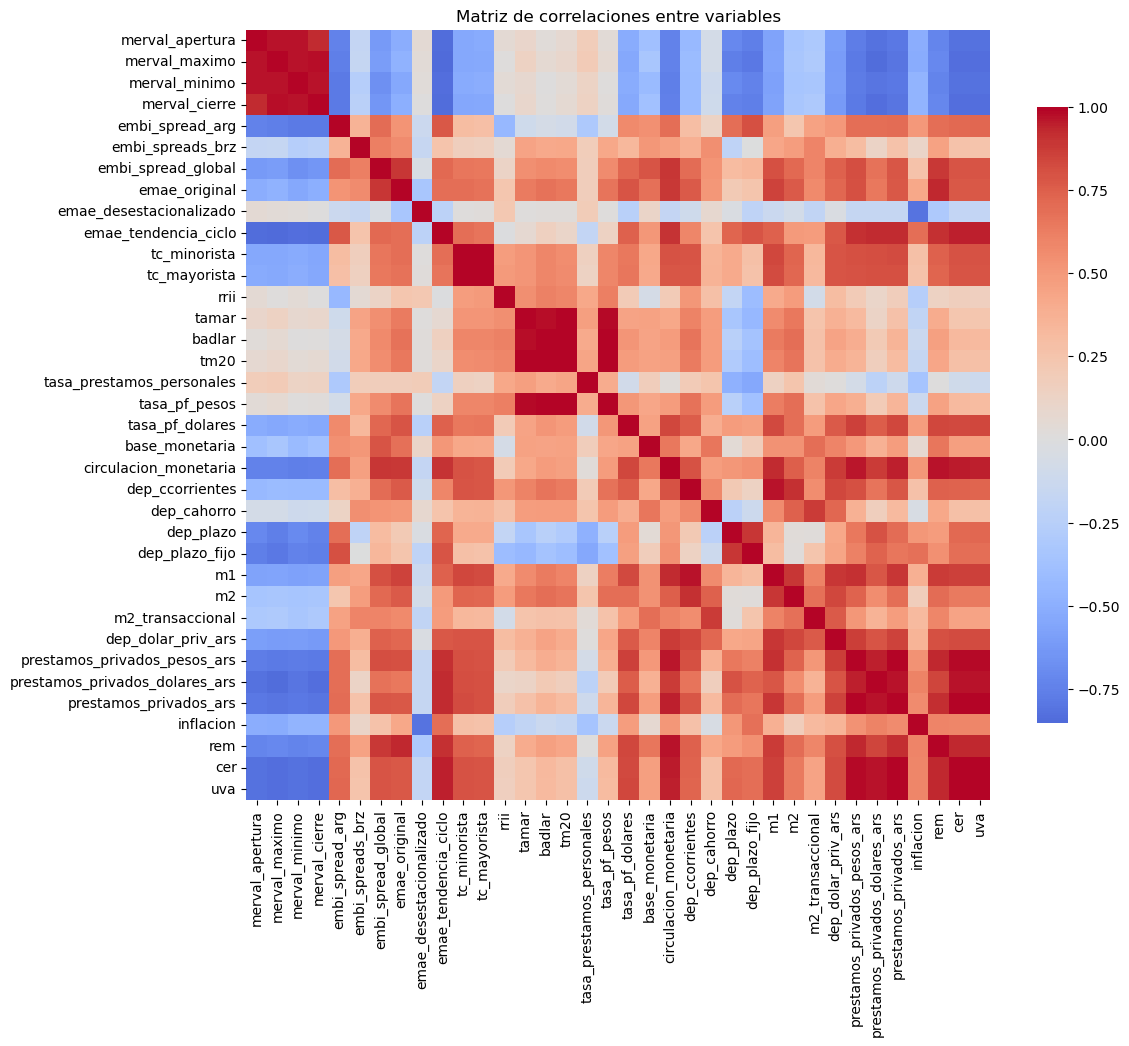

In [71]:
#1. Análisis estadístico previo.
#a. Eliminamos la columna 'fecha' y calculamos la matriz de correlaciones.
corr_matrix = series_temporales.drop(columns=['fecha']).corr()

#b. Mostramos la matriz.
print(corr_matrix)

#c. visualizamos con un mapa de calor.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, cbar_kws={'shrink': .8})
plt.title('Matriz de correlaciones entre variables')
plt.show()

##### 2. Análisis conceptual.

In [72]:
#1. Con el único precio del Merval que me voy a quedar es con el de apertura, ya que sería Data Leakeage utilizar las demás.
series_temporales.drop(["merval_maximo","merval_minimo","merval_cierre"],axis=1,inplace=True)

In [73]:
#2. Mercado financiero local e internacional.
# embi_spread_arg → mide riesgo país argentino, impacta directamente en valuaciones y flujos hacia equity local.
# embi_spreads_brz → referencia regional, ayuda a distinguir si el movimiento es idiosincrático argentino o regional.
# embi_spread_global → mide apetito global por riesgo; buen predictor en contextos de estrés global.

In [74]:
#3. Tipo de cambio y reservas.
# tc_mayorista / tc_minorista → el tipo de cambio suele anticipar o acompañar movimientos del equity argentino (devaluación = caída en USD, pero subas nominales en ARS).
# rrii (reservas internacionales) → indicador de fortaleza macro, política monetaria y confianza.

In [75]:
#4. Tasas e instrumentos financieros ----> reflejan el costo del dinero. Cambios en tasas reales afectan valuación de acciones (vía DCF y flujos futuros).
# Vamos a elegir solamente BADLAR para evitar multicolinealidad.
#series_temporales.drop(["tamar","tm20", "tasa_pf_pesos", "tasa_pf_dolares","tasa_prestamos_personales"],axis=1,inplace=True)
series_temporales.drop(["tamar","tm20","tasa_prestamos_personales"],axis=1,inplace=True)

In [76]:
#5. Variables monetarias.
# base_monetaria, m1, m2_transaccional → reflejan liquidez del sistema. En Argentina, expansión monetaria suele correlacionar con subas nominales del Merval (no reales).
# Se descartan dep_ccorrientes, dep_cahorro, dep_plazo, dep_plazo_fijo, dep_dolar_priv_ars ya que todas son componentes de M1 o M2. Y m2 ya que está muy correlacionada con m2_transaccional.
series_temporales.drop(["dep_ccorrientes", "dep_cahorro", "dep_plazo", "dep_plazo_fijo", "dep_dolar_priv_ars","m2"],axis=1,inplace=True)

In [77]:
#6. Actividad real.
# emae_tendencia_ciclo → indicador del ciclo económico real argentino.
# Se descartan emae_original y emae_desestacionalizado para evitar colinealidad. 
# Además, emae_tendencia_ciclo captura la tendencia de largo plazo y el ciclo económico subyacente, sin el ruido diario/mensual. 
# Es más estable y predictivo para un índice bursátil que responde a expectativas macro, no a movimientos mensuales aislados.
series_temporales.drop(["emae_original","emae_desestacionalizado"],axis=1,inplace=True)

In [78]:
#7. Expectativas e inflación.
# inflación: importante para variables nominales (Merval en ARS).
# REM: anticipa expectativas.
# CER/ UVA: capturan indexación y costo de financiamiento ----> Vamos a descatarlas porque aportan información derivada de inflacion (el efecto conceptual ya lo estamos capturando).
series_temporales.drop(["cer","uva"],axis=1,inplace=True)

In [79]:
#8. Préstamos.
# Me quedo solamente con prestamos_privados_pesos_ars.
# Se descarta prestamos_privados_dolares_ars y prestamos_privados_ars porque están muy correlacionados.
series_temporales.drop(["prestamos_privados_dolares_ars","prestamos_privados_ars"],axis=1,inplace=True)

In [80]:
print("En total me quedo con {} columnas regresoras para predecir el precio de apertura del Merval.".format(len(series_temporales.columns)-2))

En total me quedo con 17 columnas regresoras para predecir el precio de apertura del Merval.


#### E. Análisis básicos en el Dominio del Tiempo, y refinamiento del dataset.

In [81]:
#1. Corregimos datos incorrectos.
#a. Merval 24/03/2024 fue feriado, se elimina la fila (el dato además de ser outlier es incorecto).
series_temporales = series_temporales[series_temporales["fecha"] != "2024-03-24"]

In [82]:
#2. Imputamos los datos faltantes --> Las ST para que funcione la TTF requiere que el delta t de las muestras sea constante. Además, posteriormente para trabajar con dos series temporales juntas vamos a necesitar que compartan los mismos intervalos de muestreo (1 dato por día).
for _, row in diccionario.iterrows():
    var = row['serie']
    freq = row['frecuencia']
    
    #a. Salteo si la variable no existe en el DataFrame (variable vieja o ya borrada/trabajada).
    if var not in series_temporales.columns:
        print(f"Advertencia: la variable '{var}' no existe. Se saltea.")
        continue

    #b. Merval.
    if var.lower() == 'merval':
        continue  # no tocamos Merval ya que es la variable a predecir, y no queremos "inventar" valores.
    
    #c. Variables diarias → interpolación lineal.
    if freq == 'diaria':
        series_temporales[var] = series_temporales[var].interpolate(method='linear')
    
    #d. Variables mensuales → forward fill (tomo el último dato).
    elif freq == 'mensual':
        series_temporales[var] = series_temporales[var].ffill()

    #e. Si aún quedan NaN al inicio (sin dato anterior), completamos hacia atrás (pasa con el primer dato de embi_spreads_brz y de embi_spread_global).
    series_temporales[var] = series_temporales[var].bfill()

Advertencia: la variable 'merval_price_return_ars' no existe. Se saltea.
Advertencia: la variable 'merval_total_return_ars' no existe. Se saltea.
Advertencia: la variable 'emae_original' no existe. Se saltea.
Advertencia: la variable 'emae_desestacionalizado' no existe. Se saltea.
Advertencia: la variable 'tamar' no existe. Se saltea.
Advertencia: la variable 'tm20' no existe. Se saltea.
Advertencia: la variable 'tasa_depositos' no existe. Se saltea.
Advertencia: la variable 'tasa_prestamos_personales' no existe. Se saltea.
Advertencia: la variable 'dep_ccorrientes' no existe. Se saltea.
Advertencia: la variable 'dep_cahorro' no existe. Se saltea.
Advertencia: la variable 'dep_plazo' no existe. Se saltea.
Advertencia: la variable 'inflacion_rem' no existe. Se saltea.
Advertencia: la variable 'cer' no existe. Se saltea.
Advertencia: la variable 'uva' no existe. Se saltea.


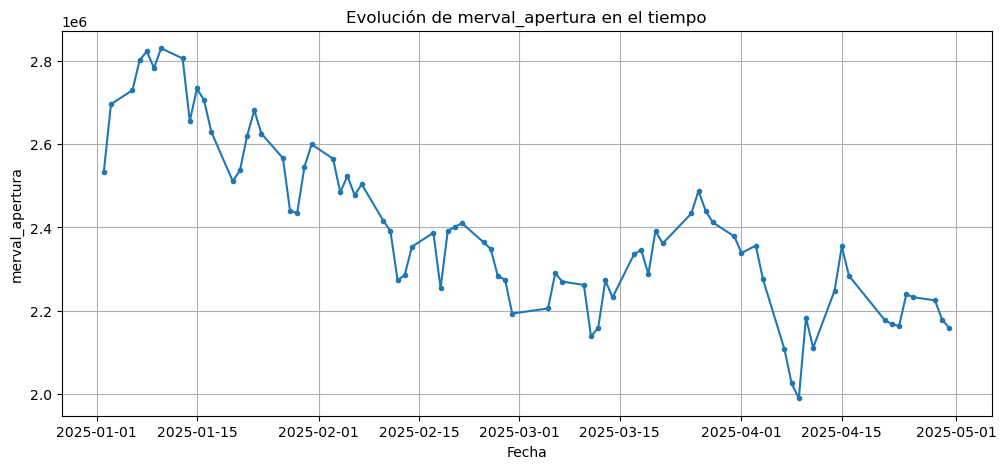

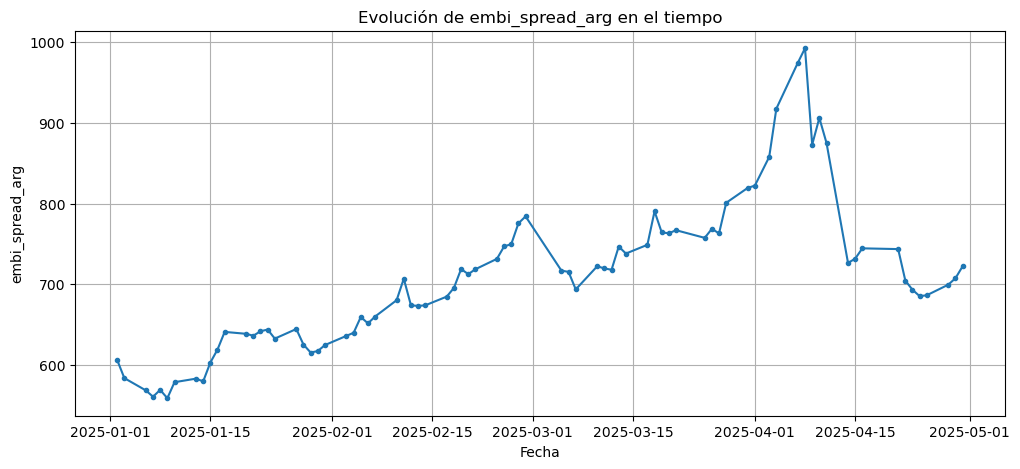

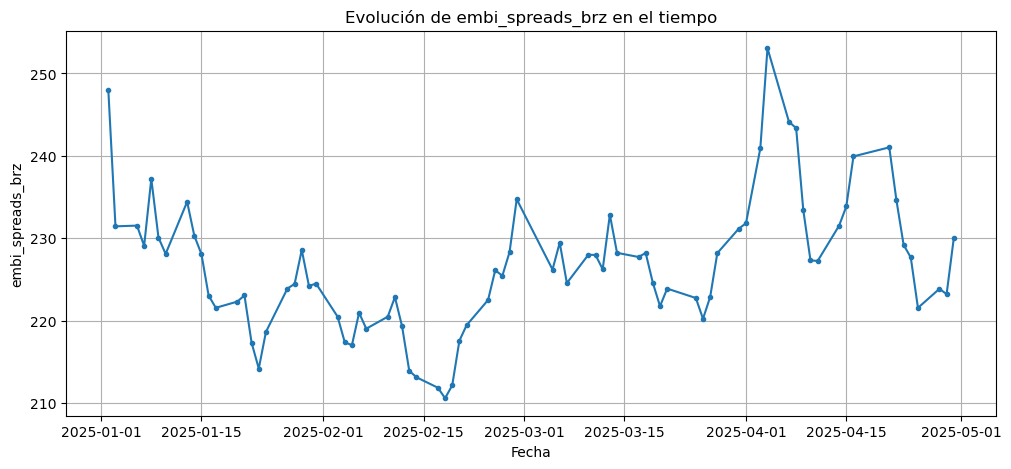

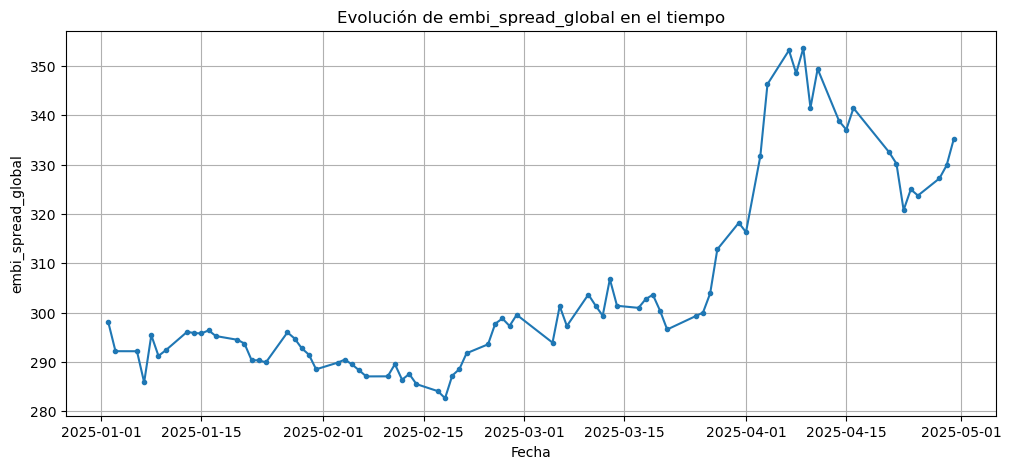

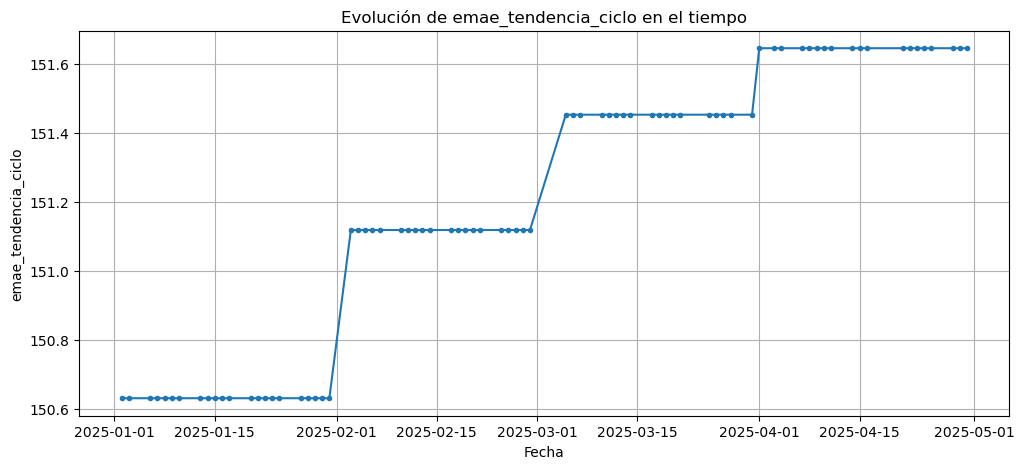

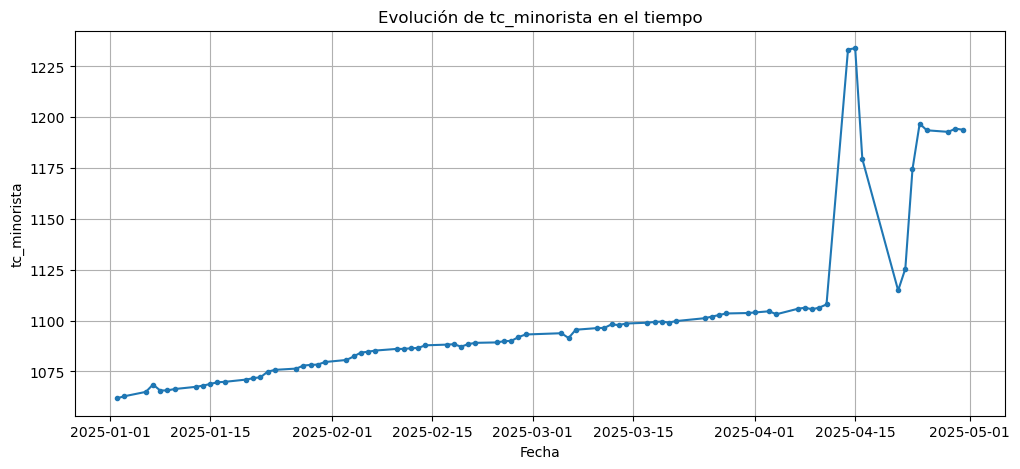

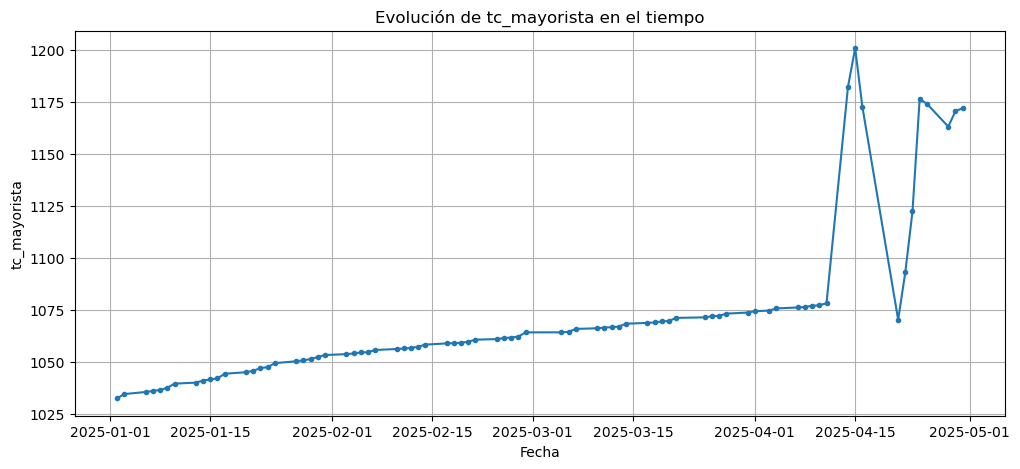

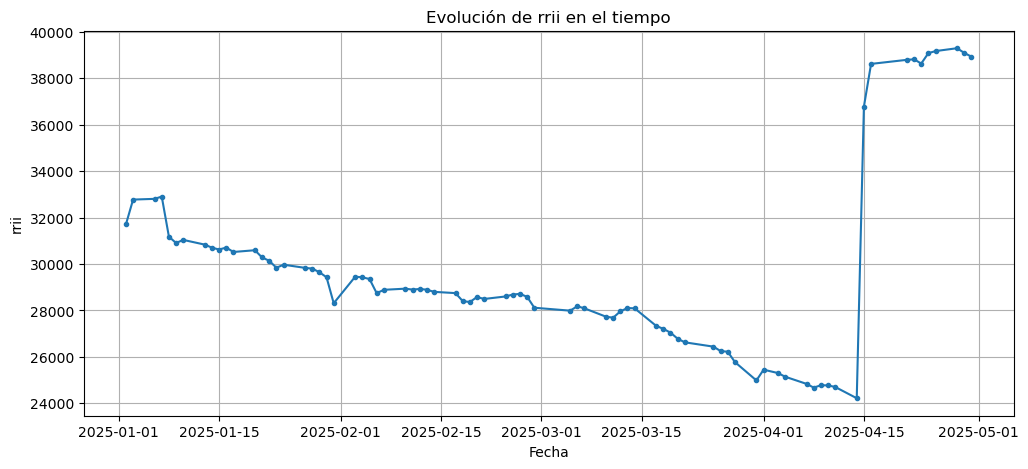

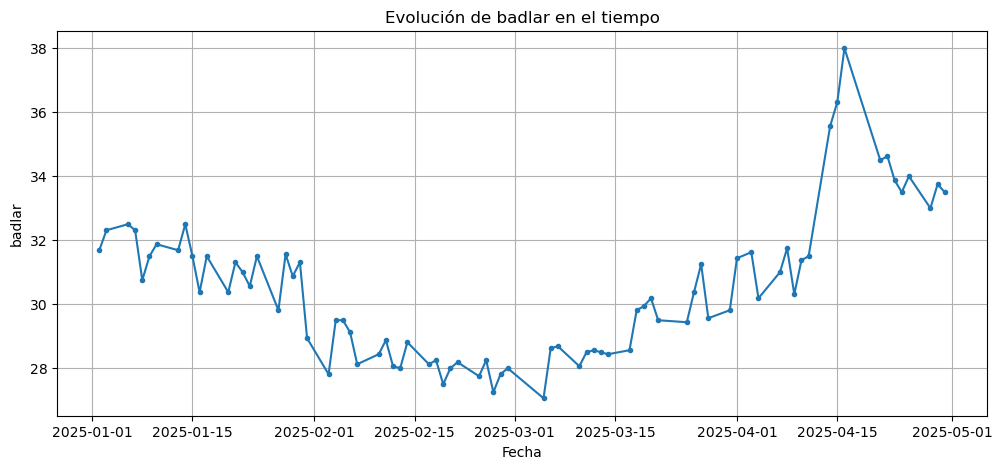

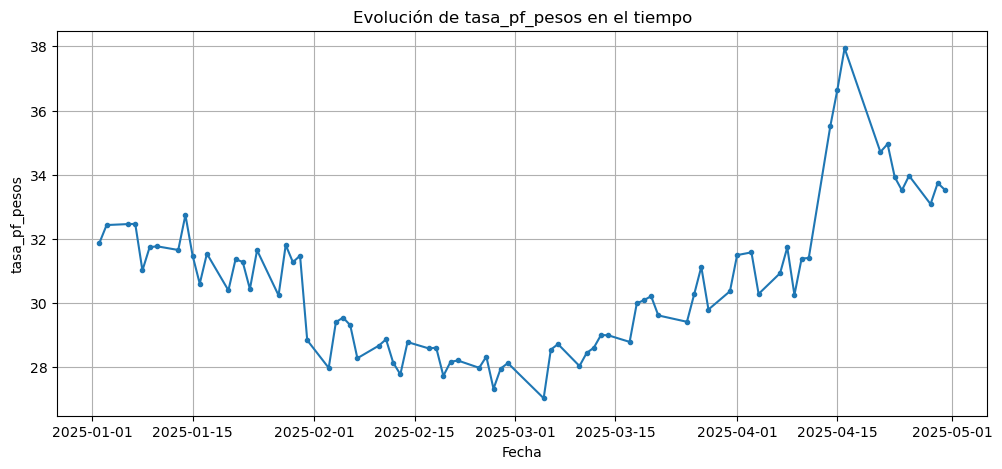

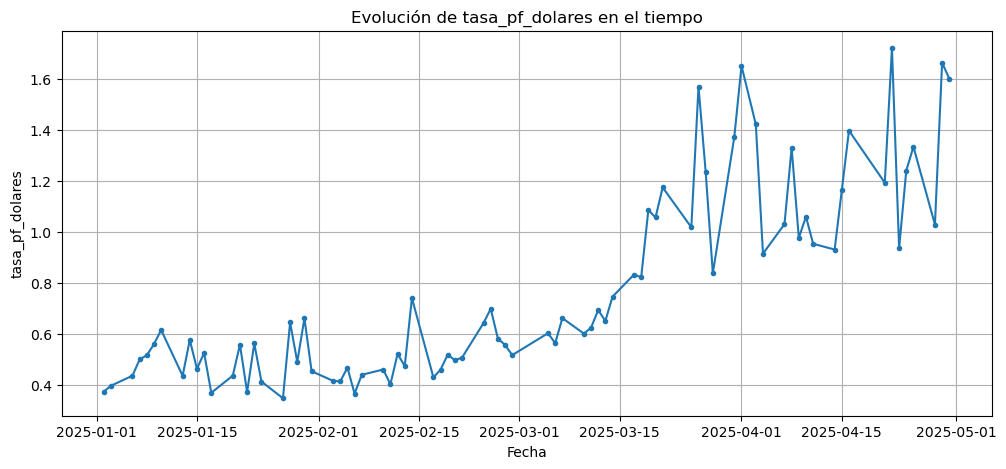

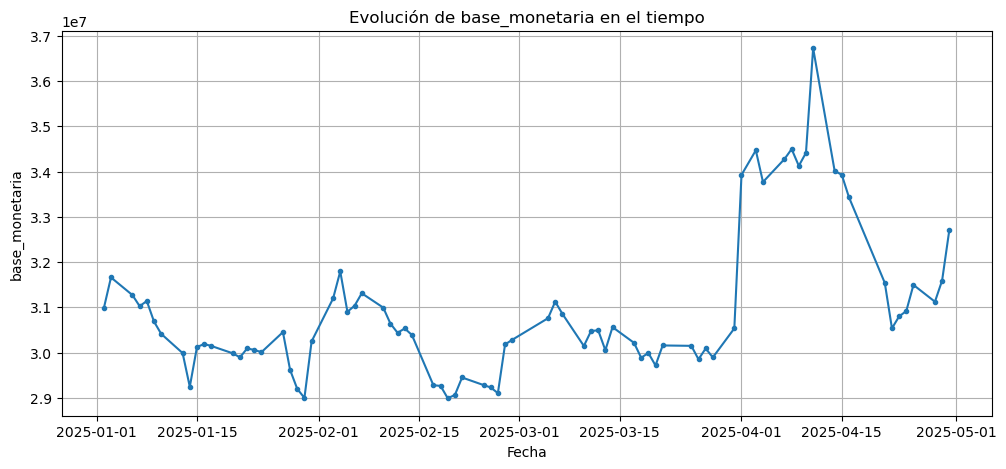

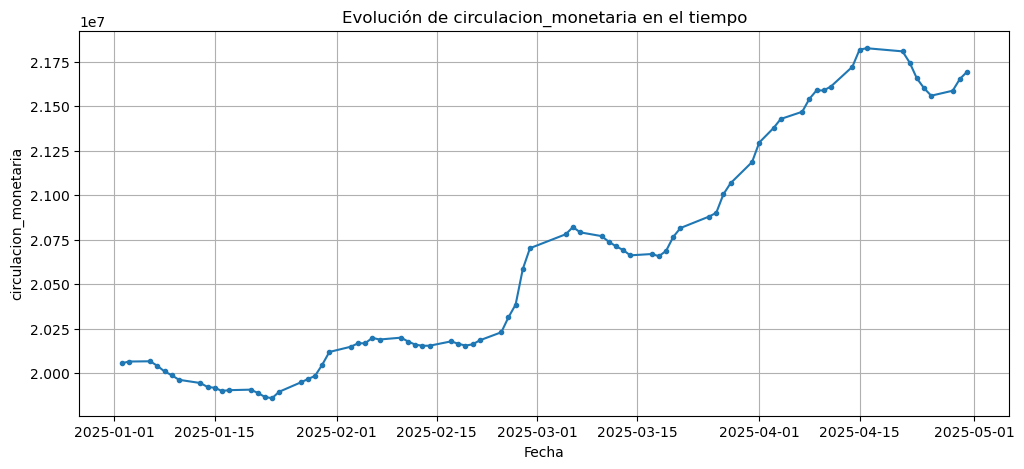

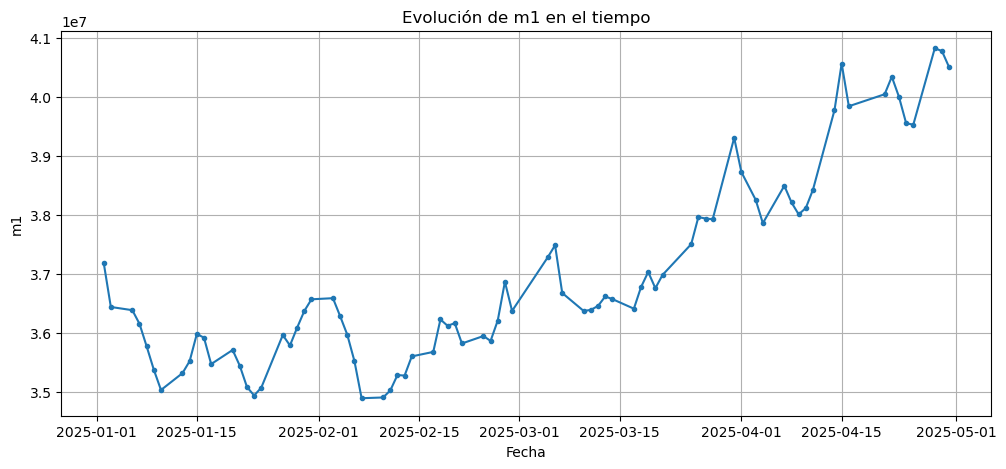

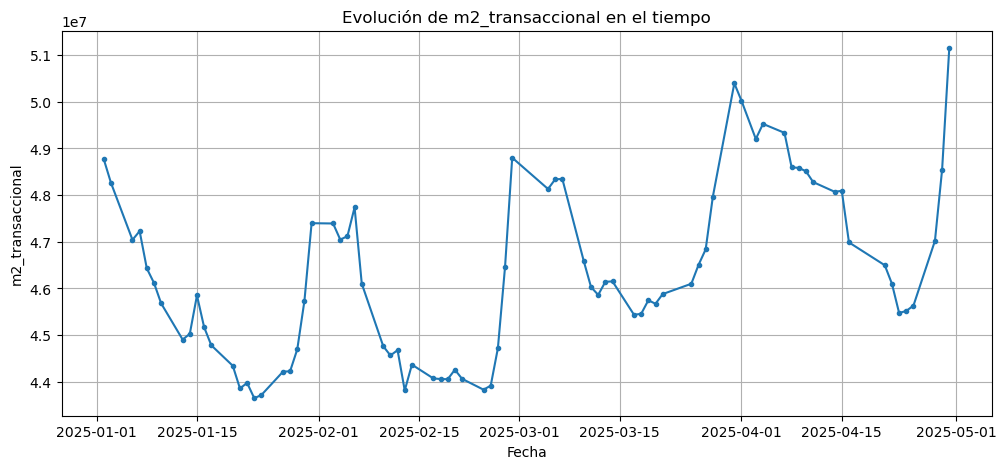

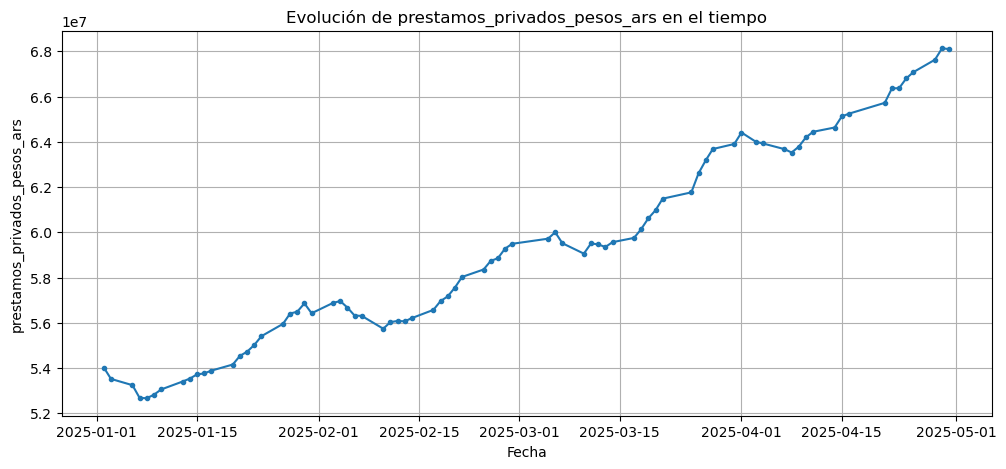

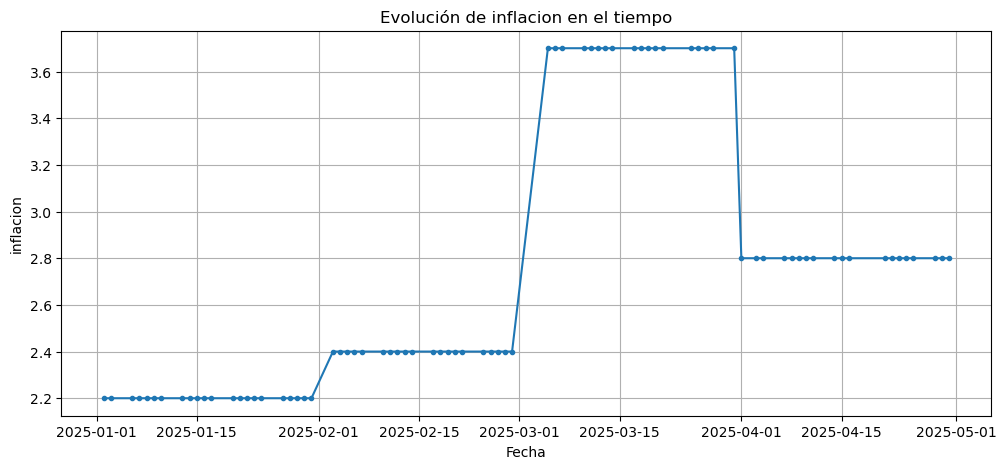

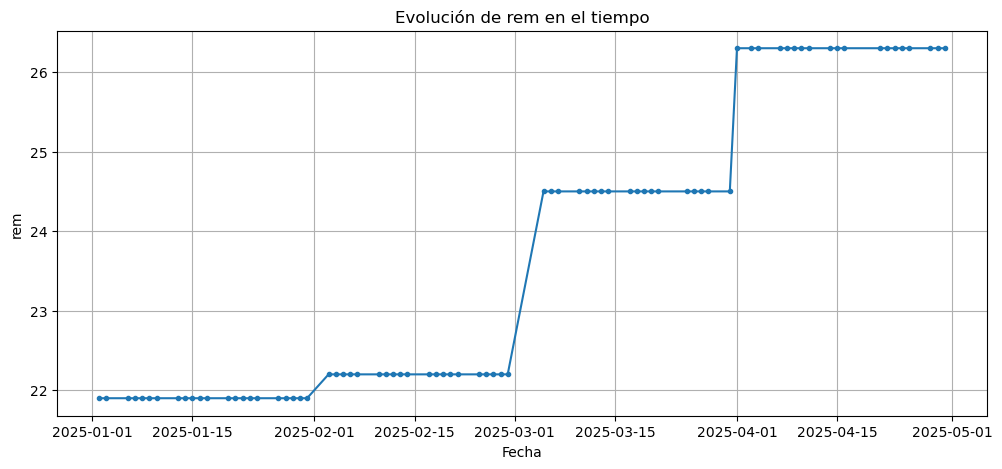

In [83]:
#3. Graficamos las columnas numéricas.
#a. Listamos las columnas numéricas (excluyendo 'fecha').
variables = series_temporales.drop(columns=["fecha"]).columns

#b. Graficamos cada variable en un gráfico separado.
for var in variables:
    plt.figure(figsize=(12,5))  # Nueva figura para cada variable
    plt.plot(series_temporales["fecha"], series_temporales[var], marker='.')
    plt.title(f"Evolución de {var} en el tiempo")
    plt.xlabel("Fecha")
    plt.ylabel(var)
    plt.grid(True)
    plt.show()

In [84]:
#4. Primer análisis de la ST del Merval.
# A simple vista, parece vislumbrarse una tendencia general alcista, teniendo en cuenta la totalidad del período analizado. Este período comienza especialmente con las elecciones PASO, primera vuelta y ballotage que resulta como presidente Milei.
# Luego de un período lentamente ascendente desde 09/2023,se distinguen distintos ciclos de frecuencias más altas, pero que tampoco parecen ser mensuales ni de cierta temporalización común.
# También cabe destacar un período de gran pendiente alcista entre 10/2024 y 01/2025, momento donde la serie alcanza un pico máximo en principios del 2025, y una posterior tendencia bajista en los meses posteriores. Como hipótesis suponemos la existencia de algún evento económico y/o político puntual (corrupción? suba del dolar? elecciones bonarenses?).
# El final de esta serie, no está excepta de estos ciclos con picos locales y valles a sus costados. Aún más, parece apreciarse mayor volatilidad en el precio de apertura del Merval. 
# Además, durante toda la serie se puede observar cierto ruido de frecuencias altas, posiblemente a cambios semanales/diarios. Y la influencia de variables predictoras.

# Acompaña nuestra hipótesis que el Riesgo País tiene una tendencia bajista. Esto también se ve en el período posterior a 01/2025 donde, mientras el Merval desciende, el Riesgo País aumenta.
# Si analizamos el posible impacto del EMAE (actividad económica), podemos ver que desde Mayo/2024 se ve una tendencia a la recuperación, que se ve correspondida con los datos del Merval desfasados. Podemos decir que el Merval estaría "explicando" al EMAE. Cabe aclarar que este tipo de indicadores suelen tener una ventana temporal para verse su impacto, como así también podemos pensar que el Merval se anticipó a partir de las expectativas generadas sobre el EMAE.
# La mayor volatilidad (frecuencias más altas) que observamos a partir de 2025 también se observa en las series temporales del tipo de cambio minorista y mayorista. Sin dudas acá puede haber una explicación del fenómeno.
# Con respecto a las reservas internacionales, dede 01/2024 se puede vislumbrar una tendencia alcista de forma volatil. Dichos cambios no se ven reflejados en el precio de apertura del Merval.
# Respecto al contexto de base monetaria, circulación monetaria, y prestámos privados en pesos, hay una tendencia general alcista, con diferentes ciclos de distintas frecuencias al interior de cada una de las series aquí planteadas.
# También podemos ver una inflación mensual con una tendencia bajista, aunque con ciertos vaivenes propios de la economía doméstica. Este dato viene acompañado por una inflación esperada (rem) también bajista, lo que nos habla de las expectativas en esta materia.

In [85]:
#5. Elimino variables post análisis que veo que no me van a servir.
series_temporales.drop(["rrii","embi_spreads_brz"],axis=1,inplace=True)

#### 5. Lags.

In [86]:
#5. Agrego lags.
#a. Función.
def add_selected_lags(
    df, 
    date_col="fecha", 
    lags=[1, 5] # Día anterior y Semana Anterior.
):
    """
    Agrega lags para columnas específicas del DataFrame.
    """
    df = df.sort_values(date_col).copy()
    df_lagged = df.copy()


    #i. Columnas macro específicas.
    cols_macro = [
        "merval_apertura","embi_spread_arg","embi_spread_global",
        "tc_minorista","tc_mayorista","badlar","tasa_pf_pesos",
        "tasa_pf_dolares","base_monetaria","circulacion_monetaria",
        "m1","m2_transaccional","prestamos_privados_pesos_ars"
    ]

    #iii. Solo usamos las que efectivamente existan en df.
    cols_target = [c for c in (cols_macro) if c in df.columns]

    #iv. Creamos los lags propiamente dichos.
    for lag in lags:
        lagged = df[cols_target].shift(lag)
        lagged.columns = [f"{c}_lag{lag}" for c in lagged.columns]
        df_lagged = pd.concat([df_lagged, lagged], axis=1)

    return df_lagged


#b. Aplicación propiamente dicha.
series_temporales_con_lags = add_selected_lags(series_temporales)

#c. Borro los primeros 6 días ya que no habia lags para atrás.
series_temporales_con_lags = series_temporales_con_lags[series_temporales_con_lags["fecha"] >= "2025-01-09"]

#### 6. Exportación.

In [88]:
#a. Exporto.
series_temporales.to_csv("../dataset_var_econom_limpio.csv",index=False)